## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

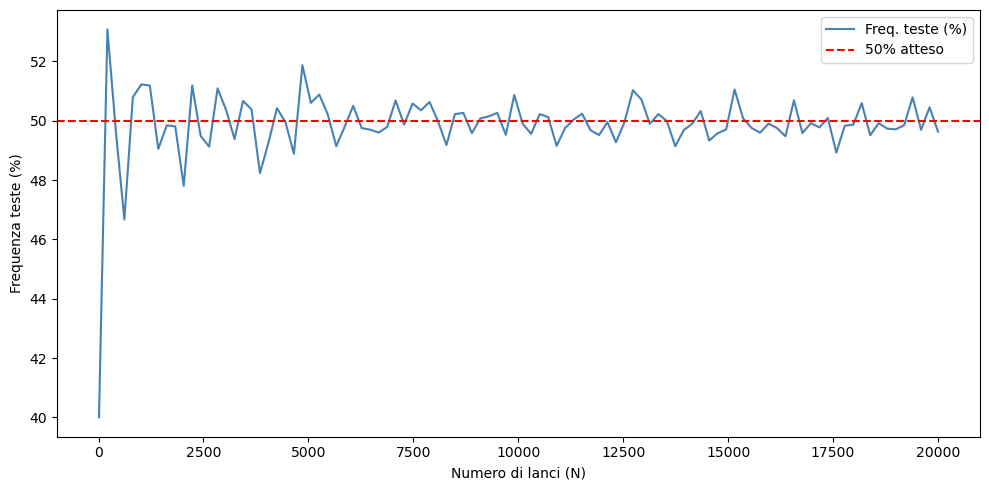

In [5]:
# 1
def lancio(N):
    array = np.random.randint(0,2,N)
    frequenza = array.sum()/N
    return frequenza

# 2
def random_len(N):
    percentuali = []
    len = np.arange(10, 20000, N)
    for l in len:
        percentuali.append(f'{round(lancio(l)*100, 2)} %')
    return percentuali


# 3
sample_sizes = np.linspace(10, 20000, 100, dtype=int)
frequenze = [lancio(n) * 100 for n in sample_sizes]

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, frequenze, color='steelblue', linewidth=1.5, label='Freq. teste (%)')
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% atteso')
plt.xlabel('Numero di lanci (N)')
plt.ylabel('Frequenza teste (%)')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [6]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Quante righe e colonne ha il dataset?
df.shape

(891, 12)

In [8]:
# Controlla quanti valori mancanti ci sono per colonna
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
most_common = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [10]:
# Controlla se ci sono righe duplicate
df.duplicated().sum()  # non ci sono duplicati

np.int64(0)

In [11]:
# Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
mean_common_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_common_age)
df.groupby('Pclass')['Age'].mean()

Pclass
1    37.048118
2    29.866958
3    26.403259
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

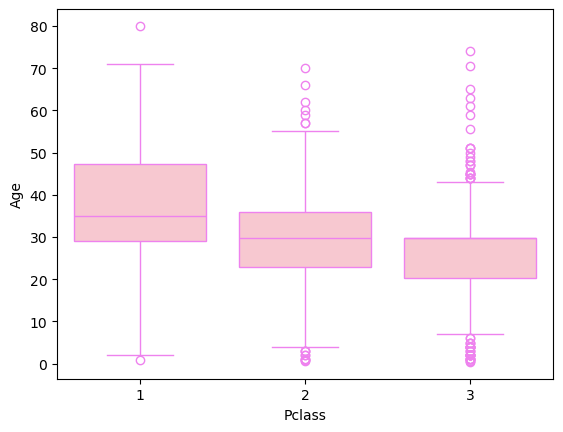

In [13]:
# Visualizza la distribuzione dell'età per classe
sns.boxplot(data=df, x='Pclass', y ='Age', color="pink", linecolor="violet")

<Axes: xlabel='Pclass', ylabel='Age'>

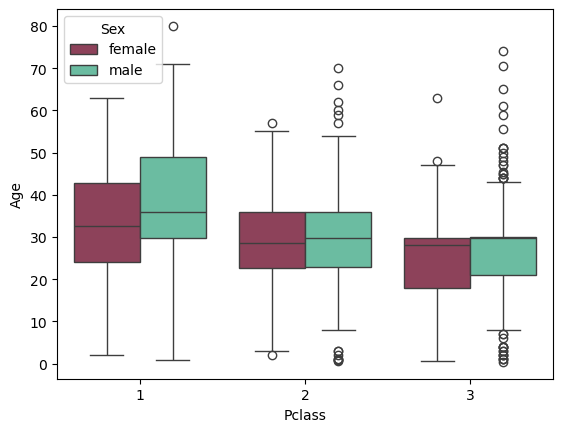

In [18]:
# Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(data=df, x='Pclass', y ='Age', hue='Sex',
            palette={'male': '#5DCAA5', 'female': '#993556'})

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [22]:
# Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [23]:
# Calcola la lunghezza e la larghezza media dei petali per specie
df.groupby('species')[['petal_length', 'petal_width']].mean()

,petal_length,petal_width
species,,
setosa,1.462,0.246
versicolor,4.260,1.326
virginica,5.552,2.026


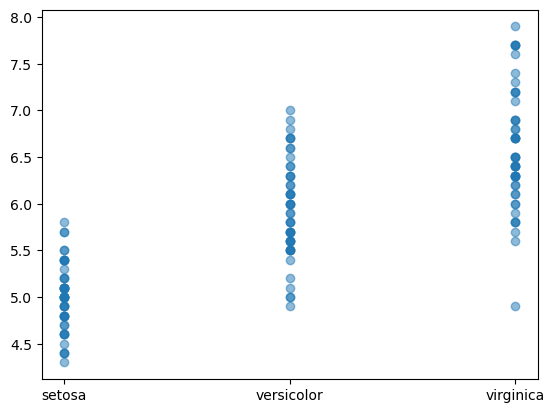

In [21]:
# Visualizza le dimensioni dei petali per specie (scatterplot)
plt.scatter(df['species'], df['sepal_length'], alpha=0.5, marker = 'o')

In [24]:
# Crea una nuova colonna per l'area del petalo e analizzala
df['petal_area'] = df['petal_length'] * df['petal_width']
df.groupby('species')['petal_area'].describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,0.3656,0.181155,0.11,0.2800,0.300,0.42,0.96
versicolor,50.0,5.7204,1.368403,3.30,4.8600,5.615,6.75,8.64
virginica,50.0,11.2962,2.157412,7.50,9.7175,11.445,12.79,15.87


<Axes: xlabel='species', ylabel='petal_area'>

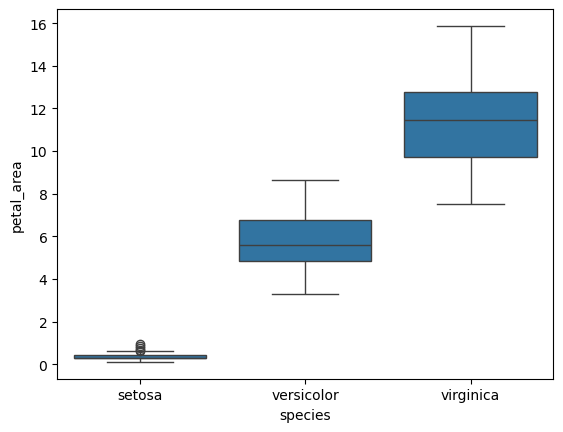

In [25]:
# Grafico della distribuzione dell'area del petalo per specie (boxplot)
sns.boxplot(data=df, x='species', y='petal_area')